# Lecture 3, part 2: A variable's distribution

An online retailer followed 4,000 customers for 180 days and recorded their 1,625 orders. This notebook describes the distribution of a variable: the order values and the customers' spending. The charts show the same data as the lecture slides, drawn with short code; the slides add formatting for the screen.

The customer-targeting exercise at the end of the notebook asks you to build your own table and charts.

## 0) Setup and data

Keep this notebook, `L3-transactions.csv` and `L3-customers.csv` in the same folder. Run the cells from top to bottom.

In [1]:
# %pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
sns.set_context("talk")

## 2.1 Load the data

`L3-transactions.csv` has one row per order; `L3-customers.csv` has one row per customer, including the customers who bought nothing.

| Column | Meaning |
| --- | --- |
| `customer_id` | The customer (in both files). |
| `acq_channel` | How the customer was acquired: Email, Organic, Paid Search or Paid Social. |
| `region` | The customer's region. |
| `order_date`, `order_value` | The date and value of an order (transactions only). |
| `margin`, `margin_rate` | The order's margin and margin ÷ order value (transactions only). |
| `n_orders_180d` | How many orders the customer placed in the 180 days (customers only). |

In [2]:
transactions = pd.read_csv("L3-transactions.csv")
customers = pd.read_csv("L3-customers.csv")
print(f"{len(transactions):,} orders, {len(customers):,} customers")
transactions.head()

1,625 orders, 4,000 customers


,customer_id,order_date,acq_channel,region,order_value,margin,margin_rate
0,1,2025-04-25,Paid Social,Midwest,13.744153,6.229426,0.453242
1,3,2025-05-26,Email,West,37.595113,19.587708,0.521017
2,4,2025-03-08,Email,Northeast,65.904285,34.496529,0.523434
3,5,2025-02-07,Paid Search,Northeast,32.427813,14.533525,0.448181
4,5,2025-05-24,Paid Search,Northeast,102.188403,50.206037,0.491309


In [3]:
customers.head()

,customer_id,acq_channel,region,n_orders_180d
0,1,Paid Social,Midwest,1
1,2,Organic,West,0
2,3,Email,West,1
3,4,Email,Northeast,1
4,5,Paid Search,Northeast,2


## 2.2 Order values: the average and other summaries

The mean is one number. The median and the percentiles describe more of the distribution: half of the orders are at or below the median, 90% at or below the 90th percentile (P90), and 99% at or below the 99th percentile (P99).

In [4]:
order_value = transactions["order_value"]
mean, median = order_value.mean(), order_value.median()
p90, p99 = order_value.quantile(0.90), order_value.quantile(0.99)
print(f"mean ${mean:.2f}, median ${median:.2f}, P90 ${p90:.2f}, P99 ${p99:.2f}, largest ${order_value.max():.2f}")

mean $59.92, median $49.28, P90 $105.91, P99 $216.69, largest $920.57


Is the average order a typical order? Draw every order in a histogram with $10 bins (section 2.3 explains histograms).

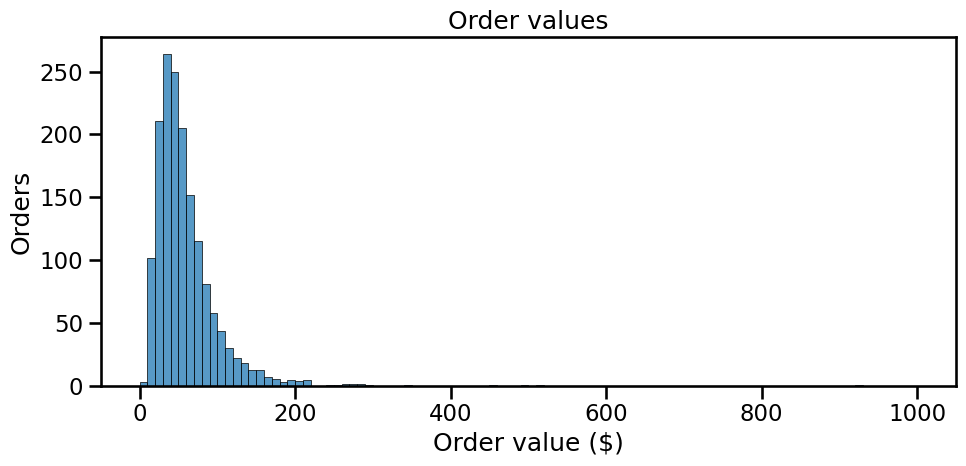

In [5]:
bins = np.arange(0, 1010, 10)   # $10 bins from $0 to $1,000

plt.figure(figsize=(10, 5))
sns.histplot(order_value, bins=bins)
plt.title("Order values")
plt.xlabel("Order value ($)")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

Most orders are smaller than the $60 average. Mark the summaries on the same histogram, and shade the long tail beyond P90.

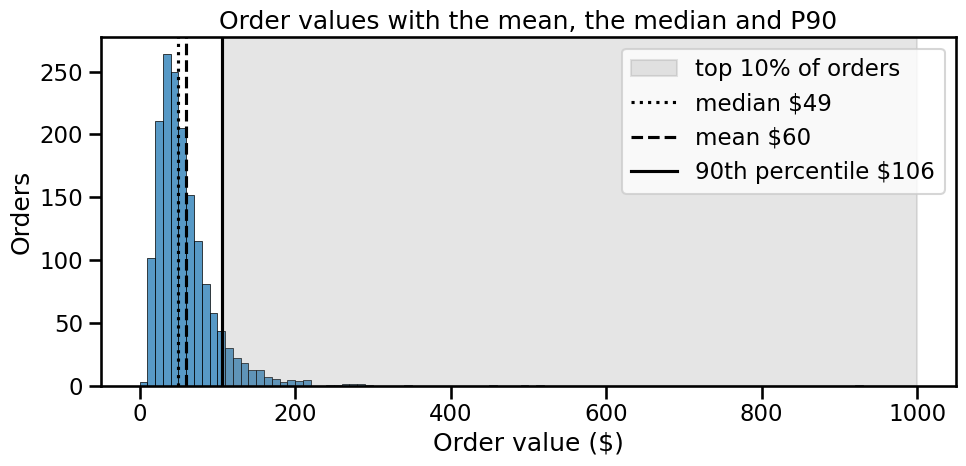

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(order_value, bins=bins)
plt.axvspan(p90, 1000, color="grey", alpha=0.2, label="top 10% of orders")
plt.axvline(median, color="black", linestyle=":", label=f"median ${median:.0f}")
plt.axvline(mean, color="black", linestyle="--", label=f"mean ${mean:.0f}")
plt.axvline(p90, color="black", linestyle="-", label=f"90th percentile ${p90:.0f}")
plt.title("Order values with the mean, the median and P90")
plt.xlabel("Order value ($)")
plt.ylabel("Orders")
plt.legend()
plt.tight_layout()
plt.show()

## 2.3 Histogram: the shape of the distribution

A histogram cuts the value range into equal bins and counts the orders in each; the height of a bar is the count. The charts in section 2.2 are histograms with $10 bins: the order values have one peak around $35–$50 and a long right tail.

### Bin width

The picture depends on the bin width. The same orders with $2 bins and with $50 bins:

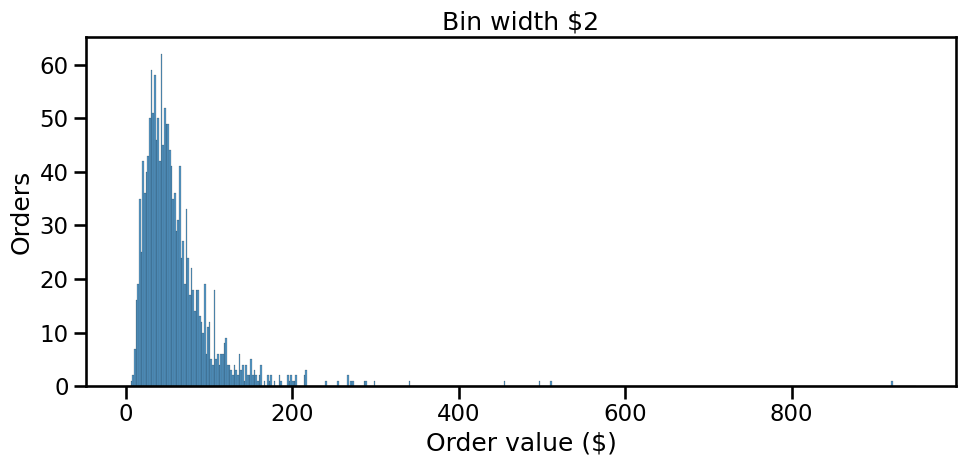

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(order_value, bins=np.arange(0, 952, 2))
plt.title("Bin width $2")
plt.xlabel("Order value ($)")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

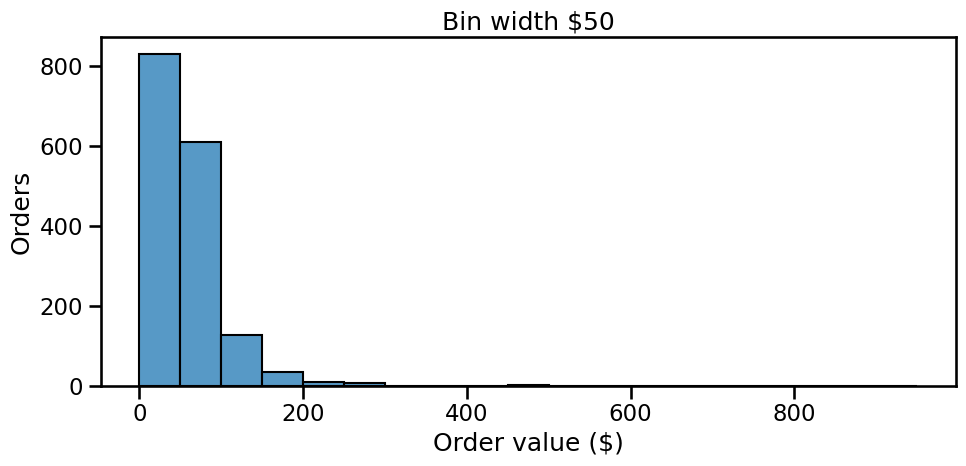

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(order_value, bins=np.arange(0, 1000, 50))
plt.title("Bin width $50")
plt.xlabel("Order value ($)")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

Both bin widths cause a problem:

- With $50 bins, the first bar ($0–$50) holds more than half of the orders, so the rise from the smallest orders up to the peak near $40 disappears. Bins that are too wide hide the shape.
- With $2 bins, each bar holds only a few orders, so neighboring bars jump up and down by chance. Bins that are too narrow show noise.

Vary the bin width a few times. Trust the patterns that persist across widths (here, one peak near $40 and a long right tail), and choose a width that is narrow enough to keep that detail and wide enough to smooth out the bin-to-bin noise. No single width is correct for every dataset.

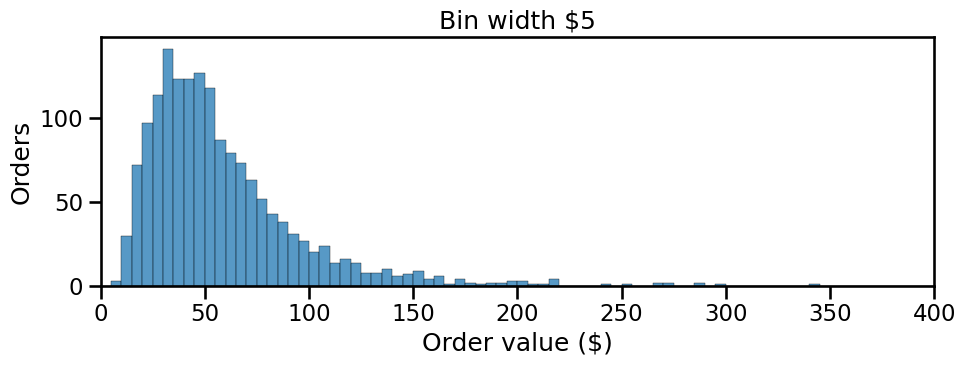

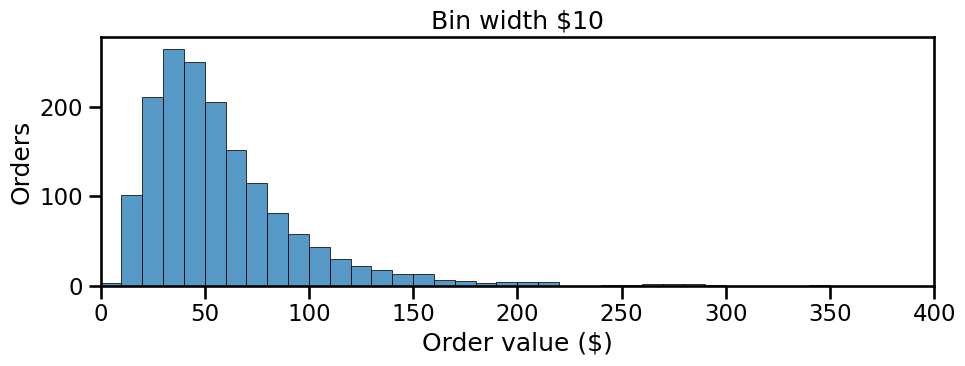

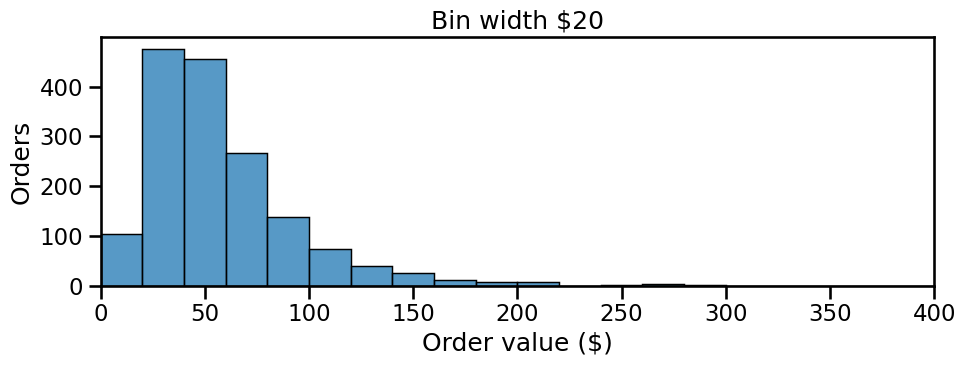

In [9]:
for width in [5, 10, 20]:
    plt.figure(figsize=(10, 4))
    sns.histplot(order_value, bins=np.arange(0, 950 + width, width))
    plt.xlim(0, 400)   # zoom in on the orders up to $400
    plt.title(f"Bin width ${width}")
    plt.xlabel("Order value ($)")
    plt.ylabel("Orders")
    plt.tight_layout()
    plt.show()

## 2.4 Box plot: the middle half, the median and the tails

The box runs from Q1 (the 25th percentile) to Q3 (the 75th percentile), so it holds the middle half of the orders; its length is the interquartile range, IQR = Q3 − Q1. The line inside the box is the median.

Compare the orders of two acquisition channels, Paid Search and Organic.

In [10]:
channels = ["Paid Search", "Organic"]
groups = [transactions.loc[transactions["acq_channel"] == channel, "order_value"] for channel in channels]
for channel, values in zip(channels, groups):
    q1, med, q3 = values.quantile([0.25, 0.5, 0.75])
    print(f"{channel}: {len(values)} orders, Q1 ${q1:.0f}, median ${med:.0f}, Q3 ${q3:.0f}, "
          f"IQR ${q3 - q1:.0f}, largest ${values.max():.0f}")

Paid Search: 547 orders, Q1 $35, median $52, Q3 $76, IQR $41, largest $511
Organic: 456 orders, Q1 $31, median $45, Q3 $67, IQR $36, largest $340


`sns.boxplot` draws one box per channel. With the order values on `x` and the channel on `y`, the boxes lie horizontally, and `order` sets their order from the top down. By default, each whisker reaches the last order within 1.5 × IQR of the box, and the orders beyond the whiskers are drawn as points; the line under the chart says so. `plt.xlim(0, 300)` cuts the axis at $300 to show the boxes in detail, and a note on the chart says how many orders lie beyond the cut.

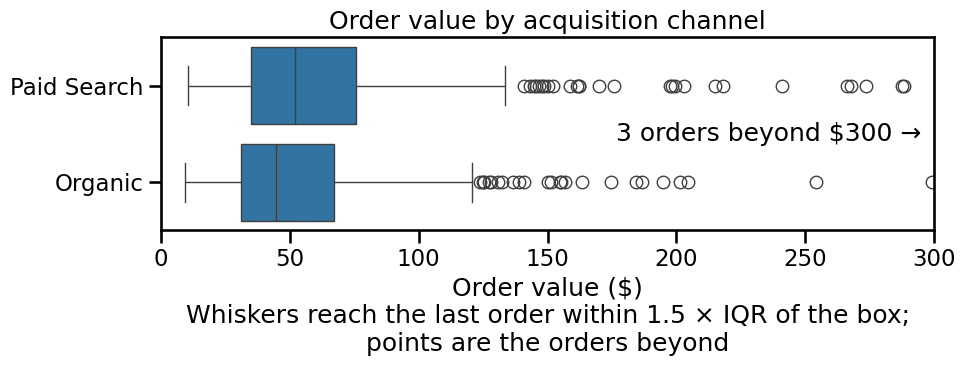

In [11]:
two_channels = transactions[transactions["acq_channel"].isin(channels)]
n_beyond = (two_channels["order_value"] > 300).sum()

plt.figure(figsize=(10, 4))
sns.boxplot(data=two_channels, x="order_value", y="acq_channel", order=channels)
plt.xlim(0, 300)
plt.text(295, 0.5, f"{n_beyond} orders beyond $300 →", ha="right", va="center")
plt.title("Order value by acquisition channel")
plt.xlabel("Order value ($)\nWhiskers reach the last order within 1.5 × IQR of the box;\npoints are the orders beyond")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Optional: Draw whiskers at the minimum and the maximum

Software differs in where it draws the whiskers. Some packages draw them to the smallest and the largest values. In seaborn and Matplotlib, the `whis` argument sets the rule: `whis=1.5`, the default, is the 1.5 × IQR rule, and `whis=(0, 100)` puts the whiskers at the 0th and the 100th percentiles, the minimum and the maximum, so no points lie beyond them.

The two cells below draw the same orders on the same axis, now uncut: first the default rule, then `whis=(0, 100)`. Whichever rule you use, state it on or under the chart.

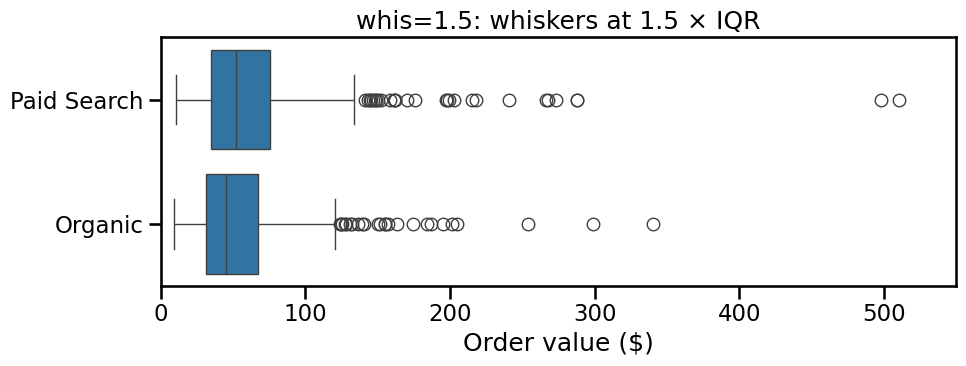

In [12]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=two_channels, x="order_value", y="acq_channel", order=channels, whis=1.5)
plt.xlim(0, 550)
plt.title("whis=1.5: whiskers at 1.5 × IQR")
plt.xlabel("Order value ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()

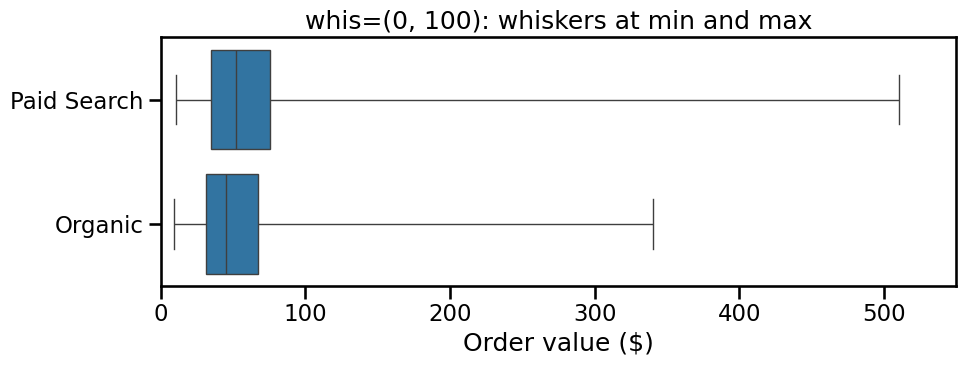

In [13]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=two_channels, x="order_value", y="acq_channel", order=channels, whis=(0, 100))
plt.xlim(0, 550)
plt.title("whis=(0, 100): whiskers at min and max")
plt.xlabel("Order value ($)")
plt.ylabel("")
plt.tight_layout()
plt.show()

With the 1.5 × IQR rule, Paid Search's upper whisker stops at $134 and 29 orders lie beyond it as points. With `whis=(0, 100)`, the whisker runs to the largest order, $511, and the long tail is hidden inside one line.

## 2.5 Customer spending: one row per customer

`transactions` has one row per order, and only customers who bought appear in it. To describe customers, build a table with one row per customer: add up each customer's orders, merge the totals onto the full customer list, and set the spending of customers without orders to $0. Round the totals to cents.

In [14]:
spending = (transactions.groupby("customer_id", as_index=False)
                        .agg(spend=("order_value", "sum"), orders=("order_value", "size")))
customer_spending = customers[["customer_id", "acq_channel", "region"]].merge(spending, on="customer_id", how="left")
customer_spending["spend"] = customer_spending["spend"].fillna(0).round(2)   # dollars and cents
customer_spending["orders"] = customer_spending["orders"].fillna(0).astype(int)

spend = customer_spending["spend"]
n_zero = (spend == 0).sum()
print(f"{len(customer_spending):,} customers; {n_zero:,} ({n_zero / len(spend):.0%}) bought nothing")
customer_spending.head()

4,000 customers; 3,111 (78%) bought nothing


,customer_id,acq_channel,region,spend,orders
0,1,Paid Social,Midwest,13.74,1
1,2,Organic,West,0.00,0
2,3,Email,West,37.60,1
3,4,Email,Northeast,65.90,1
4,5,Paid Search,Northeast,134.62,2


## 2.6 Percentile chart: the share at or below a value

The percentile chart (also called the ECDF, the empirical cumulative distribution function) shows, for each value x, the share of customers who spent x or less. Sort the values: the share at the k-th smallest value is k ÷ n. `plt.step` draws the curve as steps.

Read the chart forwards: start at a spending value, go up to the curve and across to the share. The cell prints the readings at $0, $50 and $150, and the dashed lines mark $50 and $150 on the chart.

78% of customers spent $0 or less
83% of customers spent $50 or less
95% of customers spent $150 or less


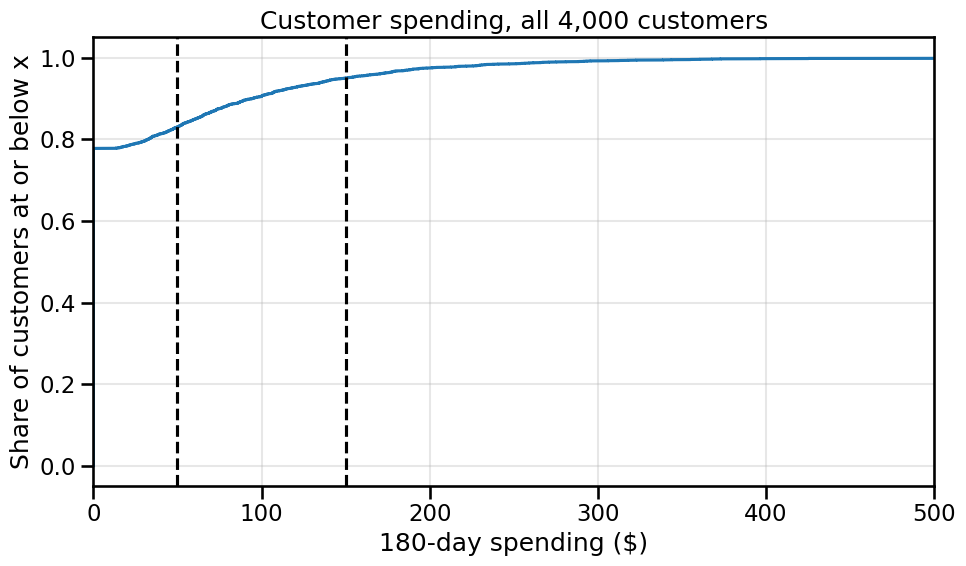

In [15]:
sorted_spend = np.sort(spend)
share_below = np.arange(1, len(sorted_spend) + 1) / len(sorted_spend)
for value in [0, 50, 150]:
    print(f"{(spend <= value).mean():.0%} of customers spent ${value} or less")

plt.figure(figsize=(10, 6))
plt.step(sorted_spend, share_below, where="post")
plt.axvline(50, color="black", linestyle="--")
plt.axvline(150, color="black", linestyle="--")
plt.xlim(0, 500)
plt.title(f"Customer spending, all {len(spend):,} customers")
plt.xlabel("180-day spending ($)")
plt.ylabel("Share of customers at or below x")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Reading the chart backwards: from a share to a cutoff

A percentile reads the chart backwards: start at a share on the y axis, go across to the curve, then down to the spending axis. `quantile` gives the same cutoffs: P75 with `quantile(0.75)` and P95 with `quantile(0.95)`.

P75 is $0. The curve jumps from 0% to 78% at $0, because 3,111 of the 4,000 customers bought nothing. Every share inside that jump, 75% included, meets the curve at $0.

P75 $0.00, P95 $149.23


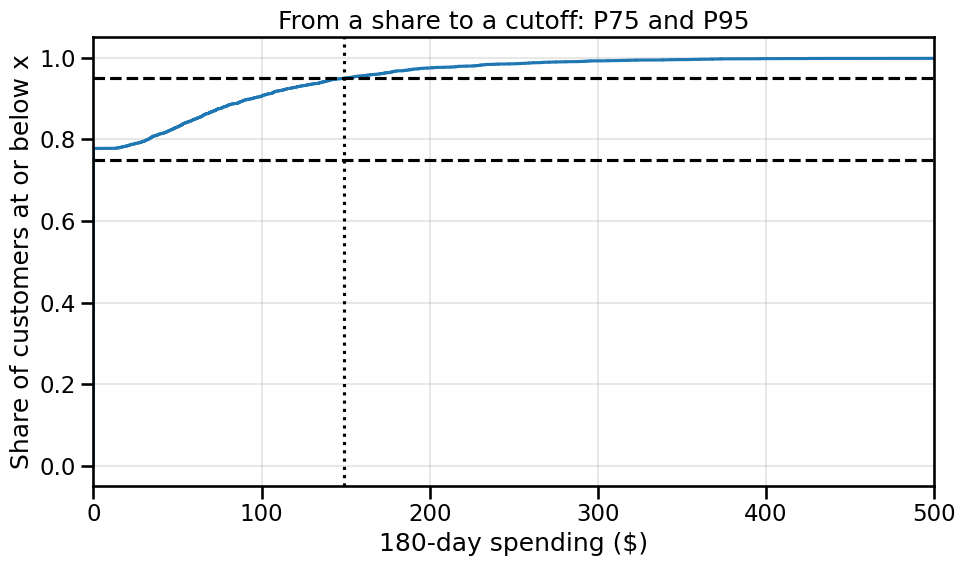

In [16]:
p75, p95 = spend.quantile(0.75), spend.quantile(0.95)
print(f"P75 ${p75:.2f}, P95 ${p95:.2f}")

plt.figure(figsize=(10, 6))
plt.step(sorted_spend, share_below, where="post")
plt.axhline(0.75, color="black", linestyle="--")
plt.axhline(0.95, color="black", linestyle="--")
plt.axvline(p95, color="black", linestyle=":")
plt.xlim(0, 500)
plt.title("From a share to a cutoff: P75 and P95")
plt.xlabel("180-day spending ($)")
plt.ylabel("Share of customers at or below x")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.7 Pareto chart: revenue by acquisition channel

A Pareto chart sorts the categories from the largest to the smallest and adds a line of the cumulative share of the total. `plt.twinx()` adds a second y axis, on the right, for the share.

In [17]:
channel_revenue = (transactions.groupby("acq_channel")["order_value"].sum()
                               .sort_values(ascending=False).to_frame("revenue"))
channel_revenue["share"] = channel_revenue["revenue"] / channel_revenue["revenue"].sum()
channel_revenue["cumulative_share"] = channel_revenue["share"].cumsum()
channel_revenue.round(3)

,revenue,share,cumulative_share
acq_channel,,,
Paid Search,34517.939,0.354,0.354
Organic,25276.816,0.260,0.614
Email,19806.507,0.203,0.817
Paid Social,17776.388,0.183,1.000


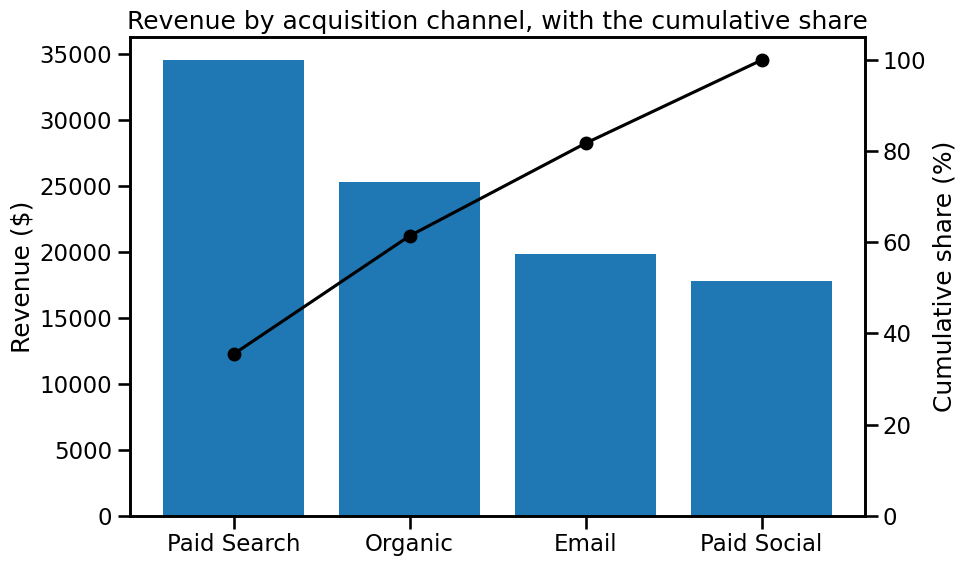

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(channel_revenue.index, channel_revenue["revenue"])
plt.ylabel("Revenue ($)")
share_axis = plt.twinx()   # the second y axis, for the cumulative share
share_axis.plot(channel_revenue.index, 100 * channel_revenue["cumulative_share"], color="black", marker="o")
share_axis.set_ylim(0, 105)
share_axis.set_ylabel("Cumulative share (%)")
plt.title("Revenue by acquisition channel, with the cumulative share")
plt.tight_layout()
plt.show()

## 2.8 Lorenz curve of customer spending

The Lorenz curve sorts the customers from the smallest spender to the largest and shows, for each share of customers, their cumulative share of revenue. If every customer spent the same amount, the curve would follow the diagonal. The dashed reference lines mark the reading at 90% of customers: down to the customer axis and across to the revenue axis.

In [19]:
cum_revenue = 100 * np.r_[0, np.cumsum(sorted_spend)] / sorted_spend.sum()
cum_customers = np.linspace(0, 100, len(cum_revenue))
zero_share = (spend == 0).mean()
bottom_90 = sorted_spend[:int(0.9 * len(sorted_spend))].sum() / sorted_spend.sum()
print(f"{zero_share:.1%} of customers bought nothing; the bottom 90% bring {bottom_90:.1%} of revenue")

77.8% of customers bought nothing; the bottom 90% bring 27.3% of revenue


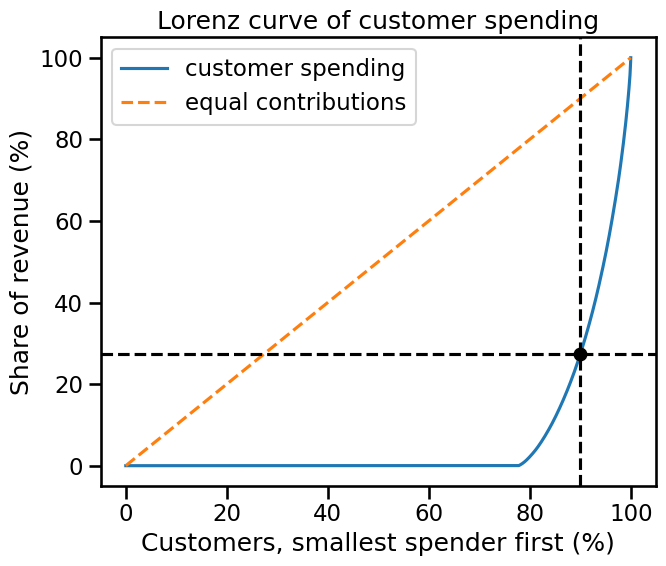

In [20]:
plt.figure(figsize=(7, 6))
plt.plot(cum_customers, cum_revenue, label="customer spending")
plt.plot([0, 100], [0, 100], linestyle="--", label="equal contributions")
plt.axvline(90, color="black", linestyle="--")                # 90% of customers
plt.axhline(100 * bottom_90, color="black", linestyle="--")   # their share of revenue
plt.plot(90, 100 * bottom_90, "o", color="black")
plt.title("Lorenz curve of customer spending")
plt.xlabel("Customers, smallest spender first (%)")
plt.ylabel("Share of revenue (%)")
plt.legend()
plt.tight_layout()
plt.show()

## Exercise: customer targeting

Work on your own with `transactions` and `customers`, which are already loaded. The worked examples looked at spending; this exercise looks at **margin**, what each order earned (the `margin` column of `transactions`). Build the tables yourself; sections 2.5, 2.6 and 2.8 are the worked examples.

Write your code in the empty code cell after each question, then answer in the text cell below it.

### Question 1

What is each customer's total margin, including customers who made no purchases? Build a table with all 4,000 customers, round each total to cents as in section 2.5, and explain how you included the nonbuyers.

*Your answer:*

### Question 2

What margin cutoff identifies the top 10% of customers? Add a percentile chart and mark the cutoff.

*Your answer:*

### Question 3

What share of customers are at or above that cutoff, and what share of total margin do they bring? Add a Lorenz curve of margin, mark the reading at 90%, and explain how it checks your margin-share calculation. What does this imply for a retention offer?

*Your answer:*

### Optional follow-up

What happens if you use the 75th percentile of margin as the cutoff for a top-25% target? Check how ties affect the share selected.

*Your answer:*